In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
#from sklearn.metrics import recall_score
from sklearn.metrics import precision_recall_fscore_support

from sklearn.metrics import roc_curve, auc , confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split


from keras.models import load_model
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop


from dataset_preparation import awgn, LoadDataset, ChannelIndSpectrogram
from deep_learning_models import TripletNet, identity_loss

In [2]:
# SPECIFIC MODULES INSTALLED MANUALLY
#%pip install keras
#%pip install tensorflow
#%pip install gdrive
#%pip install matplotlib


#!unzip -q /workspaces/work/dataset_training_aug.zip
training_dataset_path = "/workspaces/work/dataset_training_no_aug.h5"

In [22]:

file_path = training_dataset_path        
dev_range = np.arange(0,30, dtype = int), 
pkt_range = np.arange(0,15000, dtype = int), 
snr_range = np.arange(20,80)

LoadDatasetObj = LoadDataset()
    
# Load preamble IQ samples and labels.
data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)

Dataset information: Dev 1 to Dev 30, 500 packets per device.


In [25]:
print(data.shape)
print(label.shape)

(15000, 8192)
(15000, 1)


In [26]:
#SOME PREPROCESSING
data_real_values = np.real(data).reshape(data.shape[0], 1, data.shape[1])
#data_real_values = data_real_values/np.max(data_real_values)
data_real_values.shape
data_real_values_train, data_real_values_test, label_train, label_test = train_test_split(data_real_values, label, test_size=0.2)

# HYPERPAMETER TUNNING
# learning rate of optimiser, high epochs for low lr
# padding in layer 1 and corresponding maxpooling layers in cnn_model

# NOTES
# default adam with binary_crossentropy not good, but lr=0.0001
# 0.001 sgd with binary_crossentropy good
# default focalbinary_crossentropy with default adam good
# combimed cnn+lstm with 0.001 rms prop good 

In [27]:
print(data_real_values.shape)
print(data_real_values_train.shape)
print(data_real_values_test.shape)



(15000, 1, 8192)
(12000, 1, 8192)
(3000, 1, 8192)


In [79]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, MaxPooling1D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


cnn_model = Sequential()
cnn_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(1, 8192)))
#cnn_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model.add(Dropout(0.2))
cnn_model.add(Conv1D(64, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Conv1D(128, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Conv1D(512, kernel_size=3, activation='relu', padding='same'))
cnn_model.add(Flatten())
cnn_model.add(Dense(64, activation='relu'))
cnn_model.add(Dense(29, activation='relu'))

#cnn_model.summary()

/home/codespace/.python/current/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
# Define the LSTM model
lstm_model = Sequential()
lstm_model.add(LSTM(64, activation='relu', input_shape=(1, 8192)))
lstm_model.add(Dense(128, activation='relu'))
lstm_model.add(Dropout(0.5))
lstm_model.add(Dense(1, activation='sigmoid'))



In [41]:
cnn_lstm_model = Sequential()
cnn_lstm_model.add(Conv1D(filters=32, kernel_size=3, activation='relu', padding='same', input_shape=(1, 8192)))
#cnn_lstm_model.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_lstm_model.add(Dropout(0.2))
cnn_lstm_model.add(Conv1D(64, kernel_size=1, activation='relu'))
cnn_lstm_model.add(Conv1D(64, kernel_size=1, activation='relu'))
# cnn_lstm_model.add(Flatten())
# cnn_lstm_model.add(Dense(64, activation='relu'))

cnn_lstm_model.add(LSTM(64, activation='relu'))
cnn_lstm_model.add(Dense(128, activation='relu'))
#cnn_lstm_model.add(Dropout(0.5))
cnn_lstm_model.add(Dense(1, activation='sigmoid'))

In [80]:
model_to_train = cnn_model

loss1 = keras.losses.CategoricalFocalCrossentropy()
loss2 = keras.losses.CategoricalCrossentropy()

#optimizer = keras.optimizers.Adam(learning_rate=0.001) #https://keras.io/api/optimizers/adam/
optimizer = keras.optimizers.RMSprop(learning_rate=0.1) # https://keras.io/api/optimizers/rmsprop/
#optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/

model_to_train.compile(optimizer=optimizer, loss=loss1, metrics=['accuracy'])

train_history = model_to_train.fit(data_real_values_train, label_train, 
                                   validation_data = (data_real_values_test, label_test),
                                   epochs=1, batch_size=32)

375/375 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.0337 - loss: 633.0837 - val_accuracy: 0.0370 - val_loss: 581.4135


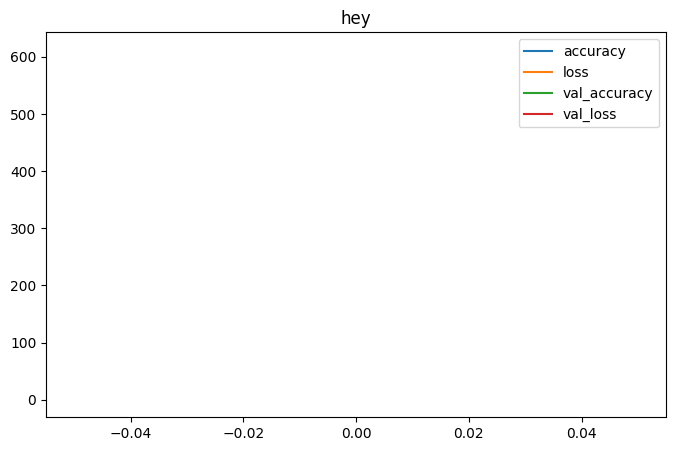

In [81]:
import pandas as pd
pd.DataFrame(train_history.history).plot(figsize=(8,5))
plt.title(f'hey')
# plt.savefig('./Plots/Base_model/7.')
plt.show()

In [82]:
# data_real_values_test, label_train, label_testa
all_labels = np.unique(label)
predictions = model_to_train.predict(data_real_values_test)
confusion_matrix = metrics.confusion_matrix(label_test, predictions)
precision_recall_fscore_support(label_test, predictions, average='macro')
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = all_labels)
cm_display.plot()
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


ValueError: Classification metrics can't handle a mix of multiclass and multiclass-multioutput targets

In [35]:
print(train_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


# SPECTROGRAM 

In [63]:
def train_feature_extractor(
    file_path = 
    '/workspaces/work/dataset_training_no_aug.h5'
        # './dataset/Train/dataset_training_aug.h5'  
        , 
    dev_range = np.arange(0,30, dtype = int), 
    pkt_range = np.arange(0,499, dtype = int), 
    snr_range = np.arange(20,80)
                            ):

                            
    '''
    train_feature_extractor trains an RFF extractor using triplet loss.
    
    INPUT: 
        FILE_PATH is the path of training dataset.
        
        DEV_RANGE is the label range of LoRa devices to train the RFF extractor.
        
        PKT_RANGE is the range of packets from each LoRa device to train the RFF extractor.
        
        SNR_RANGE is the SNR range used in data augmentation. 
        
    RETURN:
        FEATURE_EXTRACTOR is the RFF extractor which can extract features from
        channel-independent spectrograms.
    '''
    
    LoadDatasetObj = LoadDataset()
    
    # Load preamble IQ samples and labels.
    data, label = LoadDatasetObj.load_iq_samples(file_path, 
                                                 dev_range, 
                                                 pkt_range)
        
    # Add additive Gaussian noise to the IQ samples.
    data = awgn(data, snr_range)
    
    ChannelIndSpectrogramObj = ChannelIndSpectrogram()
    
    # Convert time-domain IQ samples to channel-independent spectrograms.
    data = ChannelIndSpectrogramObj.channel_ind_spectrogram(data)
    
    return data, label
    

In [64]:
spectrogram_data, spectrogram_label = train_feature_extractor()

# # VISUALISE A SAMPLE
# test_sample = data[3].reshape(102,62)
# plt.figure(figsize=(6, 3.2))
# plt.imshow(test_sample, cmap='viridis', interpolation='nearest')
# plt.colorbar()
# plt.title('ColorMap')
# plt.show()

Dataset information: Dev 1 to Dev 30, 500 packets per device.


In [66]:
spectrogram_data.shape

(14970, 102, 62, 1)

In [68]:
total_samples, height, width, _ = spectrogram_data.shape
spectrogram_data_reshaped = spectrogram_data.reshape(total_samples, height, width)
spectrogram_data_reshaped.shape

# data_real_values_train2, data_real_values_test2, label_train2, label_test2 = train_test_split(spectrogram_data, 
#                                                                     label, 
#                                                                     test_size=0.2, 
#                                                                     shuffle= True)

(14970, 102, 62)

In [70]:
import tensorflow as tf
import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Conv1D, Conv2D, MaxPooling1D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout


cnn_model2 = Sequential()
cnn_model2.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same', input_shape=(height, width, 1)))
#cnn_model2.add(MaxPooling1D(pool_size=2, padding='same'))
#cnn_model2.add(Dropout(0.2))
cnn_model2.add(Conv2D(64, kernel_size=1, activation='relu'))
cnn_model2.add(Conv2D(64, kernel_size=1, activation='relu'))
cnn_model2.add(Flatten())
cnn_model2.add(Dense(64, activation='relu'))
cnn_model2.add(Dense(30, activation='sigmoid'))

#cnn_model2.summary()

In [71]:
model_to_train = cnn_model2

loss1 = keras.losses.CategoricalFocalCrossentropy()
loss2 = keras.losses.CategoricalCrossentropy()

#optimizer = keras.optimizers.Adam(learning_rate=0.0001) #https://keras.io/api/optimizers/adam/
optimizer = keras.optimizers.RMSprop(learning_rate=0.1) # https://keras.io/api/optimizers/rmsprop/
#optimizer = keras.optimizers.SGD(learning_rate=0.001) #https://keras.io/api/optimizers/sgd/

model_to_train.compile(optimizer=optimizer, loss=loss1, metrics=['accuracy'])

train_history = model_to_train.fit(spectrogram_data_reshaped, spectrogram_label, 
                                   epochs=100, batch_size=32)

Epoch 1/100
468/468 ━━━━━━━━━━━━━━━━━━━━ 103s 217ms/step - accuracy: 0.0330 - loss: 1080.9202
Epoch 2/100
 95/468 ━━━━━━━━━━━━━━━━━━━━ 1:22 222ms/step - accuracy: 0.0315 - loss: 1085.6157

KeyboardInterrupt: 

In [ ]:
np.unique()